# Fresnel Output Exploration
This notebook loads `fresnel.out`, inspects its structure, parses numeric columns, and produces quick visualizations (amplitude, phase, and optional 2D intensity).

# 1) Load and Inspect `fresnel.out`

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-muted")

# Path to fresnel.out in the workspace root
fresnel_path = Path("fresnel_parallel.out")

# Peek at the header/comment lines
with fresnel_path.open("r") as f:
    head_lines = [next(f) for _ in range(5)]
print("First few lines:\n", "".join(head_lines))

First few lines:
 # w          y          Re(F)       Im(F)
  1.000000e-01  1.000000e-01  +1.00803484e+00  -2.04286307e+01
  1.000000e-01  2.000000e-01  +1.03809017e+00  -2.01255267e+01
  1.000000e-01  3.000000e-01  +1.08619148e+00  -1.96269246e+01
  1.000000e-01  4.000000e-01  +1.14945556e+00  -1.89425228e+01



# 2) Parse Data into Structured Arrays

In [4]:
def load_fresnel(path: Path) -> pd.DataFrame:
    """Load fresnel.out skipping comment lines and return DataFrame with columns w,y,re,im."""
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    data = np.loadtxt(path, comments="#")  # assumes 4 columns
    if data.ndim == 1:
        data = data[None, :]  # handle single-line file
    df = pd.DataFrame(data, columns=["w", "y", "re", "im"])
    return df


df = load_fresnel(fresnel_path)
df.head()

,w,y,re,im
0,0.1,0.1,1.008035,-20.428631
1,0.1,0.2,1.038090,-20.125527
2,0.1,0.3,1.086191,-19.626925
3,0.1,0.4,1.149456,-18.942523
4,0.1,0.5,1.224047,-18.085586


# 3) Plot Field Amplitude vs Position

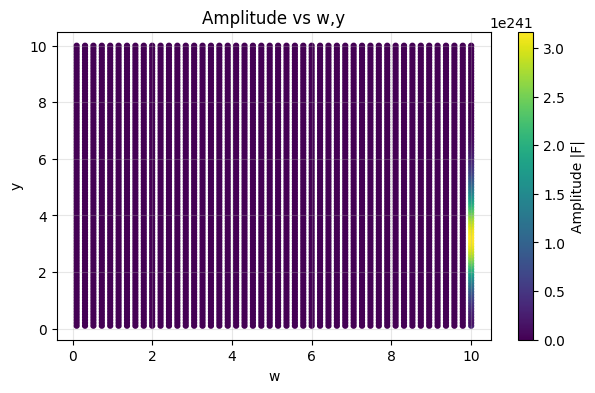

In [5]:
amp = np.hypot(df["re"], df["im"])
fig, ax = plt.subplots(figsize=(7,4))
scatter = ax.scatter(df["w"], df["y"], c=amp, s=12, cmap="viridis")
cb = fig.colorbar(scatter, ax=ax, label="Amplitude |F|")
ax.set_xlabel("w")
ax.set_ylabel("y")
ax.set_title("Amplitude vs w,y")
ax.grid(True, alpha=0.3)
plt.show()

# 4) Plot Phase vs Position

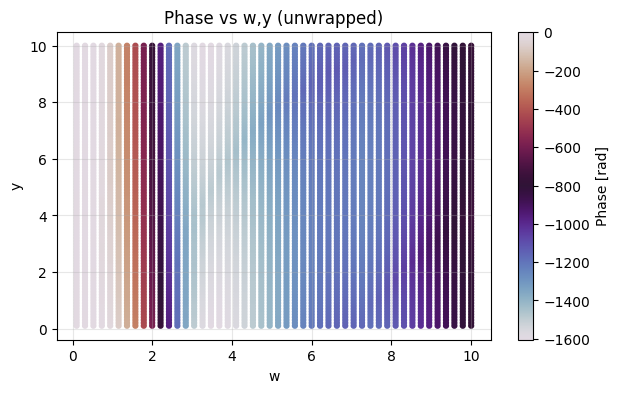

In [6]:
phase = np.unwrap(np.angle(df["re"] + 1j * df["im"]))
fig, ax = plt.subplots(figsize=(7,4))
sc = ax.scatter(df["w"], df["y"], c=phase, s=12, cmap="twilight")
fig.colorbar(sc, ax=ax, label="Phase [rad]")
ax.set_xlabel("w")
ax.set_ylabel("y")
ax.set_title("Phase vs w,y (unwrapped)")
ax.grid(True, alpha=0.3)
plt.show()

# 5) 2D Heatmap of Intensity (if grid data)

In [7]:
unique_w = np.unique(df["w"])
unique_y = np.unique(df["y"])
intensity = amp**2

can_grid = len(unique_w) * len(unique_y) == len(df)
print(f"Can reshape to grid? {can_grid} (w: {len(unique_w)}, y: {len(unique_y)}, N: {len(df)})")

if can_grid:
    # Assume data is ordered by w major, y minor or vice versa; try both
    try_order = [("w-major", (len(unique_w), len(unique_y))), ("y-major", (len(unique_y), len(unique_w)))]
    reshaped = None
    extent = None
    for label, shape in try_order:
        try:
            arr = intensity.to_numpy().reshape(shape)
            # Infer axis mapping based on shape trial
            if label == "w-major":
                extent = [unique_y.min(), unique_y.max(), unique_w.min(), unique_w.max()]
            else:
                extent = [unique_w.min(), unique_w.max(), unique_y.min(), unique_y.max()]
            reshaped = arr
            chosen = label
            break
        except ValueError:
            continue
    if reshaped is not None:
        fig, ax = plt.subplots(figsize=(6,5))
        im = ax.imshow(reshaped, origin="lower", aspect="auto", cmap="magma")
        fig.colorbar(im, ax=ax, label="Intensity |F|^2")
        ax.set_title(f"Intensity heatmap ({chosen})")
        plt.show()
    else:
        print("Could not reshape intensity to a grid; showing scatter instead.")
        plt.figure(figsize=(6,5))
        plt.scatter(df["w"], df["y"], c=intensity, s=10, cmap="magma")
        plt.colorbar(label="Intensity |F|^2")
        plt.xlabel("w")
        plt.ylabel("y")
        plt.title("Intensity scatter")
        plt.show()
else:
    print("Data not on a full grid; skipping heatmap.")

Can reshape to grid? True (w: 48, y: 100, N: 4800)


/opt/anaconda3/lib/python3.13/site-packages/matplotlib/colorbar.py:1106: RuntimeWarning: overflow encountered in add
  self._values = 0.5 * (self._boundaries[:-1] + self._boundaries[1:])
/opt/anaconda3/lib/python3.13/site-packages/matplotlib/ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale
/opt/anaconda3/lib/python3.13/site-packages/matplotlib/ticker.py:2221: RuntimeWarning: overflow encountered in multiply
  ticks = np.arange(low, high + 1) * step + best_vmin
/opt/anaconda3/lib/python3.13/site-packages/matplotlib/ticker.py:771: RuntimeWarning: overflow encountered in scalar power
  if abs_min // 10 ** oom != abs_max // 10 ** oom)
/opt/anaconda3/lib/python3.13/site-packages/matplotlib/ticker.py:772: RuntimeWarning: overflow encountered in scalar power
  if (abs_max - abs_min) / 10 ** oom <= 1e-2:
/opt/anaconda3/lib/python3.13/site-packages/matplotlib/ticker.py:778: RuntimeWarning: overflow encountered in scalar power
  if abs_max /

OverflowError: cannot convert float infinity to integer

<Figure size 600x500 with 2 Axes>

# 6) Save Figures and Export Processed Data

6.5) Real & Imaginary Parts vs w (fixed y)

Plotting for y = 0.200000, w < 8


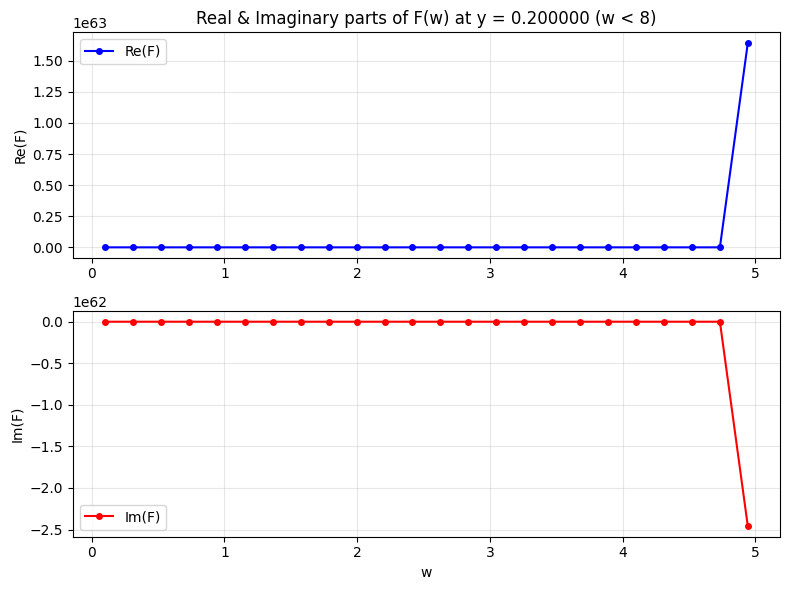

In [11]:
# Find closest y value to 1.0 if exact match doesn't exist
target_y = 0.2
closest_y = df["y"].iloc[(df["y"] - target_y).abs().argmin()]
df_y1 = df[(df["y"] == closest_y) & (df["w"] < 5)].sort_values("w")

print(f"Plotting for y = {closest_y:.6f}, w < 8")

# Sort by w for line plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Real part
ax1.plot(df_y1["w"], df_y1["re"], "o-", color="blue", label="Re(F)", markersize=4)
ax1.set_ylabel("Re(F)")
ax1.set_title(f"Real & Imaginary parts of F(w) at y = {closest_y:.6f} (w < 8)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Imaginary part
ax2.plot(df_y1["w"], df_y1["im"], "o-", color="red", label="Im(F)", markersize=4)
ax2.set_xlabel("w")
ax2.set_ylabel("Im(F)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save sample figures
fig_amp, ax_amp = plt.subplots(figsize=(7,4))
sc_amp = ax_amp.scatter(df["w"], df["y"], c=amp, s=12, cmap="viridis")
fig_amp.colorbar(sc_amp, ax=ax_amp, label="Amplitude |F|")
ax_amp.set_xlabel("w")
ax_amp.set_ylabel("y")
ax_amp.set_title("Amplitude vs w,y")
ax_amp.grid(True, alpha=0.3)
fig_amp.tight_layout()
fig_amp.savefig("fresnel_amplitude.png", dpi=150)
plt.close(fig_amp)

fig_phase, ax_phase = plt.subplots(figsize=(7,4))
sc_phase = ax_phase.scatter(df["w"], df["y"], c=phase, s=12, cmap="twilight")
fig_phase.colorbar(sc_phase, ax=ax_phase, label="Phase [rad]")
ax_phase.set_xlabel("w")
ax_phase.set_ylabel("y")
ax_phase.set_title("Phase vs w,y")
ax_phase.grid(True, alpha=0.3)
fig_phase.tight_layout()
fig_phase.savefig("fresnel_phase.png", dpi=150)
plt.close(fig_phase)

# Export cleaned data
out_csv = "fresnel_clean.csv"
df.assign(amp=amp, phase=phase).to_csv(out_csv, index=False)
print(f"Saved fresnel_amplitude.png, fresnel_phase.png, and {out_csv}")

Closest y to 1.2: 1.199299 (points: 50)


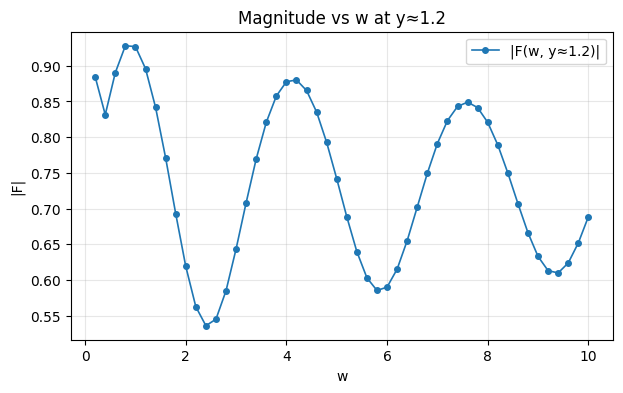

In [51]:
# Plot |F| vs w for y ≈ 1.2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

fresnel_path = Path("fresnel_parallel.out")
if not fresnel_path.exists():
    raise FileNotFoundError(f"Missing fresnel_parallel.out at {fresnel_path}")

data = np.loadtxt(fresnel_path)
w = data[:, 0]
y = data[:, 1]
re_f = data[:, 2]
im_f = data[:, 3]
mag_f = np.hypot(re_f, im_f)

target_y = 1.2
closest_y = y[np.abs(y - target_y).argmin()]
mask = np.isclose(y, closest_y, rtol=1e-6, atol=0.0)
print(f"Closest y to {target_y}: {closest_y:.6f} (points: {mask.sum()})")

w_slice = w[mask]
mag_slice = mag_f[mask]
order = np.argsort(w_slice)
w_sorted = w_slice[order]
mag_sorted = mag_slice[order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_sorted, mag_sorted, "o-", markersize=4, linewidth=1.2, label="|F(w, y≈1.2)|")
ax.set_xlabel("w")
ax.set_ylabel("|F|")
ax.set_title("Magnitude vs w at y≈1.2")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

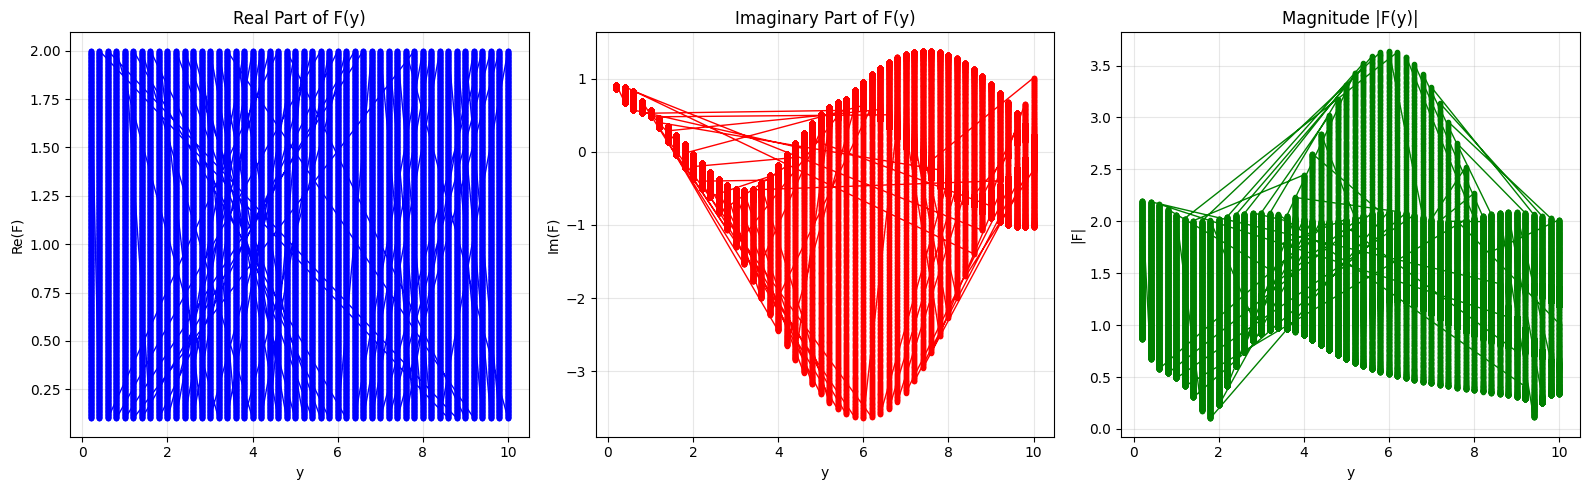

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load data from fresnel_output.txt
fresnel_path = Path("fresnel_parallel.out")
data = np.loadtxt(fresnel_path)

# Extract columns: col 1 = y, col 2 = Re(F), col 3 = Im(F)
y = data[:, 0]
re_f = data[:, 1]
im_f = data[:, 2]

 # Compute magnitude |F|
mag_f = np.sqrt(re_f**2 + im_f**2)

# Plot Re(F), Im(F), and |F| vs y
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Real part line plot
axes[0].plot(y, re_f, 'o-', markersize=3, linewidth=1, color='blue')
axes[0].set_xlabel("y")
axes[0].set_ylabel("Re(F)")
axes[0].set_title("Real Part of F(y)")
axes[0].grid(True, alpha=0.3)

# Imaginary part line plot
axes[1].plot(y, im_f, 'o-', markersize=3, linewidth=1, color='red')
axes[1].set_xlabel("y")
axes[1].set_ylabel("Im(F)")
axes[1].set_title("Imaginary Part of F(y)")
axes[1].grid(True, alpha=0.3)

# Magnitude line plot
axes[2].plot(y, mag_f, 'o-', markersize=3, linewidth=1, color='green')
axes[2].set_xlabel("y")
axes[2].set_ylabel("|F|")
axes[2].set_title("Magnitude |F(y)|")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fresnel_re_im_mag.png", dpi=150)
plt.show()


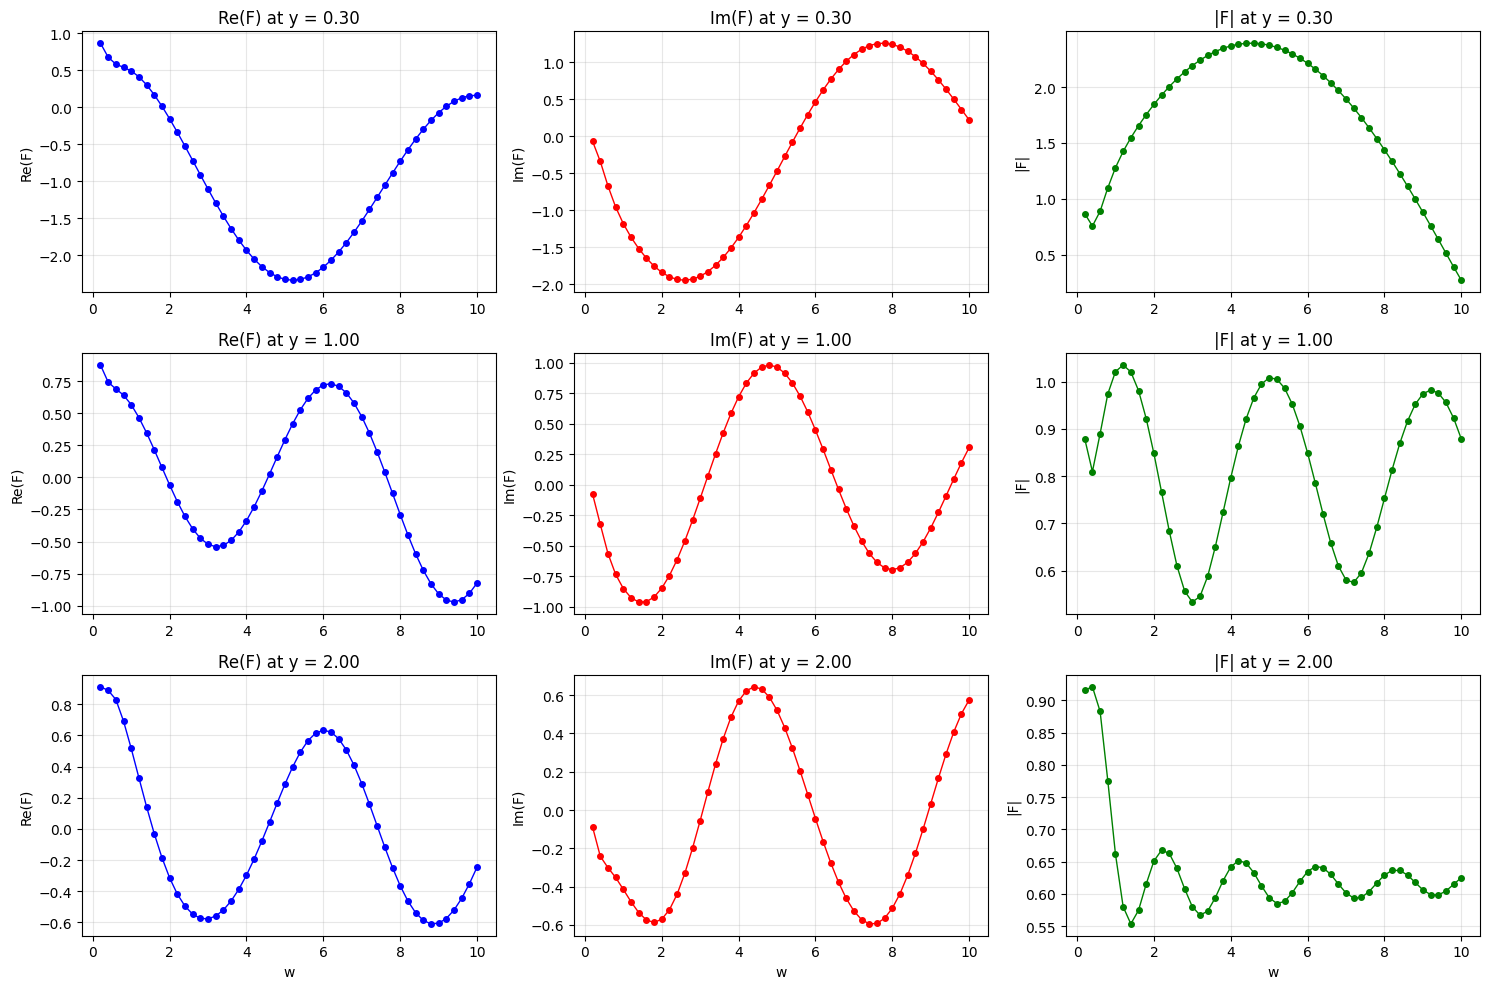

Plotted 3 y values
Saved to fresnel_vs_w.png


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load data from fresnel_output.txt (4 columns: w, y, Re(F), Im(F))
fresnel_path = Path("fresnel_parallel.out")
data = np.loadtxt(fresnel_path)

# Extract columns
w = data[:, 0]
y = data[:, 1]
re_f = data[:, 2]
im_f = data[:, 3]

# Compute magnitude |F|
mag_f = np.sqrt(re_f**2 + im_f**2)

# Target y values
target_y_vals = [0.3, 1.0, 3.0]

# Create figure with subplots for each y value
fig, axes = plt.subplots(len(target_y_vals), 3, figsize=(15, 10))

for row, target_y in enumerate(target_y_vals):
    # Find closest y value in data
    closest_y = y[np.argmin(np.abs(y - target_y))]
    mask = np.isclose(y, closest_y, rtol=1e-6)
    
    w_slice = w[mask]
    re_slice = re_f[mask]
    im_slice = im_f[mask]
    mag_slice = mag_f[mask]
    
    # Sort by w for line plotting
    sort_idx = np.argsort(w_slice)
    w_slice = w_slice[sort_idx]
    re_slice = re_slice[sort_idx]
    im_slice = im_slice[sort_idx]
    mag_slice = mag_slice[sort_idx]
    
    # Real part
    axes[row, 0].plot(w_slice, re_slice, 'o-', color='blue', markersize=4, linewidth=1)
    axes[row, 0].set_ylabel("Re(F)")
    axes[row, 0].set_title(f"Re(F) at y = {closest_y:.2f}")
    axes[row, 0].grid(True, alpha=0.3)
    
    # Imaginary part
    axes[row, 1].plot(w_slice, im_slice, 'o-', color='red', markersize=4, linewidth=1)
    axes[row, 1].set_ylabel("Im(F)")
    axes[row, 1].set_title(f"Im(F) at y = {closest_y:.2f}")
    axes[row, 1].grid(True, alpha=0.3)
    
    # Magnitude
    axes[row, 2].plot(w_slice, mag_slice, 'o-', color='green', markersize=4, linewidth=1)
    axes[row, 2].set_ylabel("|F|")
    axes[row, 2].set_title(f"|F| at y = {closest_y:.2f}")
    axes[row, 2].grid(True, alpha=0.3)

# Set x-axis label for bottom row
for col in range(3):
    axes[-1, col].set_xlabel("w")

plt.tight_layout()
plt.savefig("fresnel_vs_w.png", dpi=150)
plt.show()

print(f"Plotted {len(target_y_vals)} y values")
print(f"Saved to fresnel_vs_w.png")

Can reshape to grid? True (w: 50, y: 1000, N: 50000)


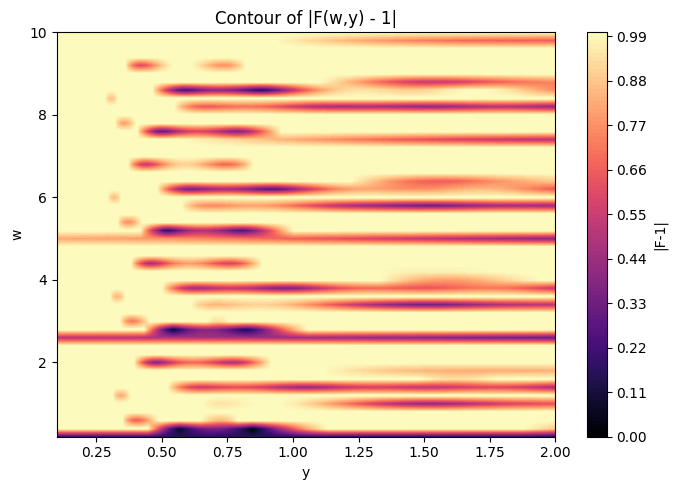

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# Re-read data fresh from file
fresnel_path = Path("fresnel_parallel.out")
raw = np.loadtxt(fresnel_path)
# Expect 4 columns: w, y, Re(F), Im(F)
df = pd.DataFrame(raw, columns=["w", "y", "re", "im"])

# |F-1|
abs_f1 = np.abs((df["re"] + 1j*df["im"]) - 1.0)

unique_w = np.unique(df["w"])
unique_y = np.unique(df["y"])

can_grid = len(unique_w) * len(unique_y) == len(df)
print(f"Can reshape to grid? {can_grid} (w: {len(unique_w)}, y: {len(unique_y)}, N: {len(df)})")

vmin, vmax = 0.0, 1.0

if can_grid:
    # assume w-major (rows = w, cols = y)
    try:
        Z = abs_f1.to_numpy().reshape(len(unique_w), len(unique_y))
        # clip to [vmin, vmax] for consistent color scaling
        Z_clipped = np.clip(Z, vmin, vmax)
        W, Y = np.meshgrid(unique_w, unique_y, indexing="ij")
        plt.figure(figsize=(7,5))
        cs = plt.contourf(Y, W, Z_clipped, levels=100, cmap="magma", vmin=vmin, vmax=vmax)
        plt.colorbar(cs, label="|F-1|")
        plt.xlabel("y")
        plt.ylabel("w")
        plt.title("Contour of |F(w,y) - 1|")
        plt.tight_layout()
        plt.savefig("fresnel_absFminus1_contour.png", dpi=150)
        plt.show()
    except ValueError:
        can_grid = False  # fall through to scatter

if not can_grid:
    plt.figure(figsize=(7,5))
    sc = plt.scatter(df["y"], df["w"], c=np.clip(abs_f1, vmin, vmax), s=10, cmap="magma", vmin=vmin, vmax=vmax)
    plt.colorbar(sc, label="|F-1|")
    plt.xlabel("y")
    plt.ylabel("w")
    plt.title("|F(w,y) - 1| (scatter)")
    plt.tight_layout()
    plt.savefig("fresnel_absFminus1_scatter.png", dpi=150)
    plt.show()

In [26]:
import numpy as np
from pathlib import Path

# Generate 5000 Gauss-Legendre roots and weights
n = 2000
roots, weights = np.polynomial.legendre.leggauss(n)

# Save to file in the project directory
output_path = Path("/Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel/gl2000")
with output_path.open("w") as f:
    for root, weight in zip(roots, weights):
        f.write(f"{root:.16e} {weight:.16e}\n")

print(f"Saved {n} Gauss-Legendre points to {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

Saved 2000 Gauss-Legendre points to /Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel/gl2000
File size: 90.8 KB


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path
from IPython.display import HTML

# Load data
fresnel_path = Path("fresnel1.out")
data = np.loadtxt(fresnel_path)
# New format: w, y1, y2, Re(F), Im(F)
w_vals = data[:, 0]
y1_vals = data[:, 1]
y2_vals = data[:, 2]
re_f = data[:, 3]
im_f = data[:, 4]

# Get unique w values
unique_w = np.unique(w_vals)
print(f"Found {len(unique_w)} unique w values from {unique_w.min():.3f} to {unique_w.max():.3f}")

# Prepare figure
fig, ax = plt.subplots(figsize=(8, 7))

# Determine color scale from all data
mag_all = np.abs(re_f + 1j * im_f)
vmin, vmax = 0, np.percentile(mag_all, 99)  # cap at 99th percentile
levels = np.linspace(vmin, vmax, 50)

# Initialize with first frame to create colorbar once
mask_0 = np.isclose(w_vals, unique_w[0], rtol=1e-6)
y1_0 = y1_vals[mask_0]
y2_0 = y2_vals[mask_0]
mag_f_0 = np.abs(re_f[mask_0] + 1j * im_f[mask_0])

contour = ax.scatter(y1_0, y2_0, c=mag_f_0, s=50, cmap='viridis', vmin=vmin, vmax=vmax)
cbar = plt.colorbar(contour, ax=ax, label="|F|")

def update_frame(frame_idx):
    ax.clear()
    w = unique_w[frame_idx]
    
    # Extract data for this w value
    mask = np.isclose(w_vals, w, rtol=1e-6)
    y1_frame = y1_vals[mask]
    y2_frame = y2_vals[mask]
    re_frame = re_f[mask]
    im_frame = im_f[mask]
    mag_frame = np.abs(re_frame + 1j * im_frame)
    
    # Plot as contour using scatter with enough points to interpolate
    # Or try to reshape into a 2D grid if data is on a regular grid
    n_unique_y1 = len(np.unique(y1_frame))
    n_unique_y2 = len(np.unique(y2_frame))
    
    if n_unique_y1 * n_unique_y2 == len(y1_frame):
        # Data is on a regular grid; reshape it
        try:
            mag_grid = mag_frame.reshape(n_unique_y1, n_unique_y2)
            y1_unique = np.unique(y1_frame)
            y2_unique = np.unique(y2_frame)
            Y1, Y2 = np.meshgrid(y2_unique, y1_unique)
            cs = ax.contourf(Y1, Y2, mag_grid, levels=levels, cmap='viridis', vmin=vmin, vmax=vmax, extend='max')
        except Exception as e:
            print(f"Failed to reshape grid for w={w}: {e}, using scatter")
            cs = ax.scatter(y1_frame, y2_frame, c=mag_frame, s=50, cmap='viridis', vmin=vmin, vmax=vmax)
    else:
        # Data is scattered; use scatter plot
        cs = ax.scatter(y1_frame, y2_frame, c=mag_frame, s=50, cmap='viridis', vmin=vmin, vmax=vmax)
    
    ax.set_xlabel("y₁")
    ax.set_ylabel("y₂")
    ax.set_title(f"|F(w, y₁, y₂)| at w = {w:.3f}")
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    
    return cs,

# Create animation
print("Creating animation...")
anim = animation.FuncAnimation(fig, update_frame, frames=len(unique_w), 
                               interval=100, blit=False, repeat=True)

# Save as mp4 (requires ffmpeg) or gif
output_path = "fresnel_evolution.mp4"
try:
    anim.save(output_path, writer='ffmpeg', fps=10, dpi=100)
    print(f"✓ Saved animation to {output_path}")
except Exception as e:
    print(f"✗ Failed to save mp4: {e}")
    # Try gif instead
    try:
        output_path = "fresnel_evolution.gif"
        anim.save(output_path, writer='pillow', fps=5)
        print(f"✓ Saved animation to {output_path}")
    except Exception as e2:
        print(f"✗ Failed to save gif: {e2}")
        print("Animation created but not saved. Display it with plt.show() or install ffmpeg/pillow")

plt.close()
print("Animation complete!")

# Display animation in notebook
HTML(anim.to_jshtml())

Found 50 unique w values from 0.200 to 10.000
Creating animation...
✓ Saved animation to fresnel_evolution.mp4
Animation complete!


Found 998001 points for w=10.0
Unique y1: 999, Unique y2: 999, Total points: 998001
✓ Plotted as regular grid (999 × 999)


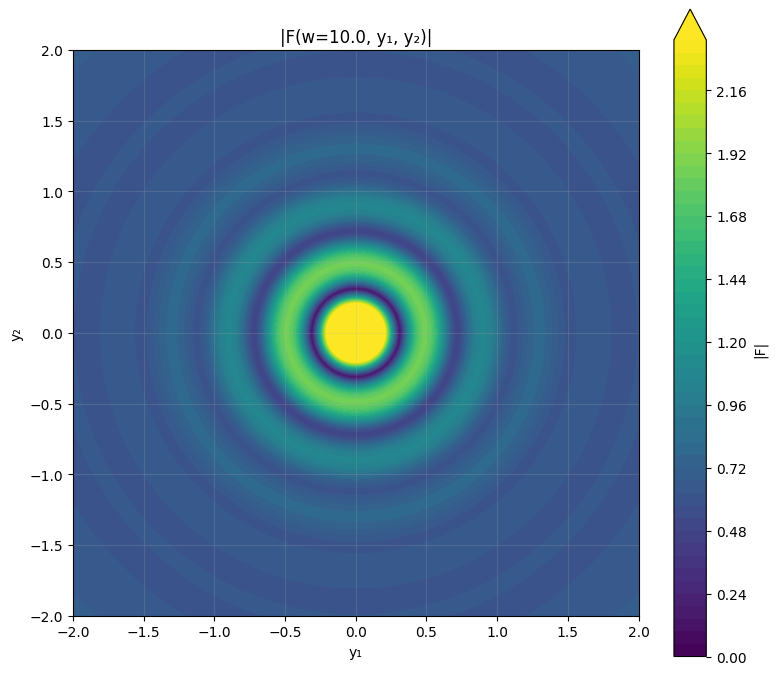

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load data
fresnel_path = Path("fresnel3.out")
data = np.loadtxt(fresnel_path)
# Format: w, y1, y2, Re(F), Im(F)
w_vals = data[:, 0]
y1_vals = data[:, 1]
y2_vals = data[:, 2]
re_f = data[:, 3]
im_f = data[:, 4]

# Extract data for w=0.2
w_target = 10.0
mask = np.isclose(w_vals, w_target, rtol=1e-6)
y1_frame = y1_vals[mask]
y2_frame = y2_vals[mask]
mag_frame = np.abs(re_f[mask] + 1j * im_f[mask])

print(f"Found {np.sum(mask)} points for w={w_target}")

# Determine color scale
mag_all = np.abs(re_f + 1j * im_f)
vmin, vmax = 0, np.percentile(mag_all, 99)
levels = np.linspace(vmin, vmax, 50)

# Check if data is on a regular grid
n_unique_y1 = len(np.unique(y1_frame))
n_unique_y2 = len(np.unique(y2_frame))

print(f"Unique y1: {n_unique_y1}, Unique y2: {n_unique_y2}, Total points: {len(y1_frame)}")

fig, ax = plt.subplots(figsize=(8, 7))

if n_unique_y1 * n_unique_y2 == len(y1_frame):
    # Data is on a regular grid; reshape it
    try:
        mag_grid = mag_frame.reshape(n_unique_y1, n_unique_y2)
        y1_unique = np.unique(y1_frame)
        y2_unique = np.unique(y2_frame)
        Y1, Y2 = np.meshgrid(y2_unique, y1_unique)
        cs = ax.contourf(Y1, Y2, mag_grid, levels=levels, cmap='viridis', vmin=vmin, vmax=vmax, extend='max')
        cbar = plt.colorbar(cs, ax=ax, label="|F|")
        print(f"✓ Plotted as regular grid ({n_unique_y1} × {n_unique_y2})")
    except Exception as e:
        print(f"✗ Failed to reshape grid: {e}, using scatter")
        cs = ax.scatter(y1_frame, y2_frame, c=mag_frame, s=50, cmap='viridis', vmin=vmin, vmax=vmax)
        cbar = plt.colorbar(cs, ax=ax, label="|F|")
else:
    # Data is scattered; use scatter plot
    cs = ax.scatter(y1_frame, y2_frame, c=mag_frame, s=50, cmap='viridis', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(cs, ax=ax, label="|F|")
    print(f"Data is scattered (not a full grid), using scatter plot")

ax.set_xlabel("y₁")
ax.set_ylabel("y₂")
ax.set_title(f"|F(w={w_target}, y₁, y₂)|")
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("fresnel_snapshot_w02.png", dpi=150)
plt.show()


In [42]:
import numpy as np
from scipy.interpolate import griddata

# Load both datasets
data_type1 = np.loadtxt("fresnel1.out")  # Type-1 (adaptive)
data_type3 = np.loadtxt("fresnel3.out")    # Type-3 (fixed)

w_target = 2.0
tol = 1e-5

# Extract Type-1 data at w_target
mask1 = np.abs(data_type1[:, 0] - w_target) < tol
y1_t1 = data_type1[mask1, 1]
y2_t1 = data_type1[mask1, 2]
F_t1 = data_type1[mask1, 3] + 1j * data_type1[mask1, 4]

# Extract Type-3 data at w_target
mask3 = np.abs(data_type3[:, 0] - w_target) < tol
y1_t3 = data_type3[mask3, 1]
y2_t3 = data_type3[mask3, 2]
F_t3 = data_type3[mask3, 3] + 1j * data_type3[mask3, 4]

print(f"Type-1: {len(y1_t1)} points, y1 range [{y1_t1.min():.3f}, {y1_t1.max():.3f}]")
print(f"Type-3: {len(y1_t3)} points, y1 range [{y1_t3.min():.3f}, {y1_t3.max():.3f}]")

# Interpolate Type-1 onto Type-3 grid
pts_t1 = np.column_stack([y1_t1, y2_t1])
pts_t3 = np.column_stack([y1_t3, y2_t3])
F_t1_interp = griddata(pts_t1, F_t1, pts_t3, method='linear')

# Compare where both are valid
valid = ~np.isnan(F_t1_interp)
rel_err = np.abs(F_t1_interp[valid] - F_t3[valid]) / (np.abs(F_t3[valid]) + 1e-10)

print(f"\nAt w={w_target}:")
print(f"  Mean relative error: {np.mean(rel_err):.2e}")
print(f"  Max relative error: {np.max(rel_err):.2e}")
print(f"  Points compared: {np.sum(valid)} / {len(F_t3)}")

if np.mean(rel_err) < 1e-2:
    print("✓ Results agree to within numerical tolerance")
else:
    print("✗ Significant discrepancy—check coefficient computation")

Type-1: 2025 points, y1 range [-2.033, 2.033]
Type-3: 998001 points, y1 range [-2.000, 2.000]

At w=2.0:
  Mean relative error: 2.36e-03
  Max relative error: 1.17e-02
  Points compared: 998001 / 998001
✓ Results agree to within numerical tolerance


In [43]:
import numpy as np
from scipy.interpolate import griddata

# Load parallel (1D radial) and FINUFFT (2D) results
par = np.loadtxt("fresnel_parallel.out")   # cols: w, y, Re, Im
f2d = np.loadtxt("fresnel1.out")           # cols: w, y1, y2, Re, Im

# Slice FINUFFT data at y2 ≈ 0 (axis)
eps = 1e-9
mask_axis = np.abs(f2d[:,2]) < eps
f2d_axis = f2d[mask_axis]

w_par, y_par = par[:,0], par[:,1]
F_par = par[:,2] + 1j*par[:,3]

w_2d, y1_2d = f2d_axis[:,0], f2d_axis[:,1]
F_2d = f2d_axis[:,3] + 1j*f2d_axis[:,4]

# Build (w,y) points for interpolation
pts_2d = np.column_stack([w_2d, y1_2d])
pts_par = np.column_stack([w_par, y_par])

# Interpolate FINUFFT onto parallel grid
F_2d_on_par = griddata(pts_2d, F_2d, pts_par, method="linear")

valid = ~np.isnan(F_2d_on_par)
rel_err = np.abs(F_2d_on_par[valid] - F_par[valid]) / (np.abs(F_par[valid]) + 1e-14)

print(f"Compared {valid.sum()} / {len(F_par)} points")
print(f"Mean rel error: {rel_err.mean():.2e}")
print(f"Max  rel error: {rel_err.max():.2e}")

Compared 50000 / 50000 points
Mean rel error: 1.58e-03
Max  rel error: 1.91e-02


Parallel:   w ∈ [0.200, 10.000], y ∈ [0.100, 2.000]
FINUFFT(y2≈0): w ∈ [0.200, 10.000], y1 ∈ [-2.772, 2.772]
FINUFFT points at y2≈0: 5618

Comparison:
  Valid points: 50000 / 50000 (100.0%)
  Mean rel error: 1.58e-03
  Max  rel error: 1.91e-02
  Median rel error: 1.15e-03


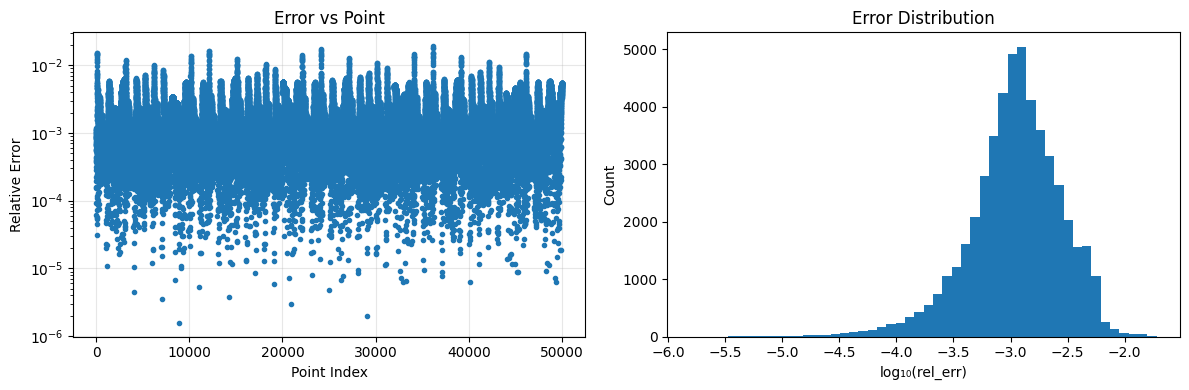


✓ Results AGREE (mean error < 1%)


In [39]:
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load parallel (1D radial) and FINUFFT (2D) results
par = np.loadtxt("fresnel_parallel.out")   # cols: w, y, Re, Im
f2d = np.loadtxt("fresnel1.out")           # cols: w, y1, y2, Re, Im

# Slice FINUFFT data at y2 ≈ 0 (axis)
eps = 1e-6  # Try larger tolerance if needed
mask_axis = np.abs(f2d[:,2]) < eps
f2d_axis = f2d[mask_axis]

w_par, y_par = par[:,0], par[:,1]
F_par = par[:,2] + 1j*par[:,3]

w_2d, y1_2d = f2d_axis[:,0], f2d_axis[:,1]
F_2d = f2d_axis[:,3] + 1j*f2d_axis[:,4]

# Debug: check overlap
print(f"Parallel:   w ∈ [{w_par.min():.3f}, {w_par.max():.3f}], y ∈ [{y_par.min():.3f}, {y_par.max():.3f}]")
print(f"FINUFFT(y2≈0): w ∈ [{w_2d.min():.3f}, {w_2d.max():.3f}], y1 ∈ [{y1_2d.min():.3f}, {y1_2d.max():.3f}]")
print(f"FINUFFT points at y2≈0: {len(w_2d)}")

# Interpolate FINUFFT onto parallel grid
pts_2d = np.column_stack([w_2d, y1_2d])
pts_par = np.column_stack([w_par, y_par])

F_2d_on_par = griddata(pts_2d, F_2d, pts_par, method="linear")

valid = ~np.isnan(F_2d_on_par)
print(f"\nComparison:")
print(f"  Valid points: {valid.sum()} / {len(F_par)} ({100*valid.sum()/len(F_par):.1f}%)")

if valid.sum() > 0:
    rel_err = np.abs(F_2d_on_par[valid] - F_par[valid]) / (np.abs(F_par[valid]) + 1e-14)
    print(f"  Mean rel error: {rel_err.mean():.2e}")
    print(f"  Max  rel error: {rel_err.max():.2e}")
    print(f"  Median rel error: {np.median(rel_err):.2e}")
    
    # Plot error distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.semilogy(rel_err, 'o', markersize=3)
    ax1.set_ylabel('Relative Error')
    ax1.set_xlabel('Point Index')
    ax1.grid(alpha=0.3)
    ax1.set_title('Error vs Point')
    
    ax2.hist(np.log10(rel_err[rel_err > 0]), bins=50)
    ax2.set_xlabel('log₁₀(rel_err)')
    ax2.set_ylabel('Count')
    ax2.set_title('Error Distribution')
    plt.tight_layout()
    plt.show()
    
    if rel_err.mean() < 1e-2:
        print("\n✓ Results AGREE (mean error < 1%)")
    else:
        print(f"\n✗ Results DISAGREE (mean error {rel_err.mean():.1%})")
else:
    print("\n✗ No overlap—grids don't intersect in (w, y) space")

w=0.2: 0.000s
w=5.5: 0.000s
w=10.7: 0.000s
w=16.0: 0.000s
w=21.2: 0.000s
w=26.5: 0.000s
w=31.7: 0.000s
w=37.0: 0.000s
w=42.2: 0.000s
w=47.5: 0.000s
w=52.7: 0.000s
w=58.0: 0.000s
w=63.2: 0.000s
w=68.5: 0.000s
w=73.7: 0.000s
w=79.0: 0.000s
w=84.2: 0.000s
w=89.5: 0.000s
w=94.7: 0.000s
w=100.0: 0.000s


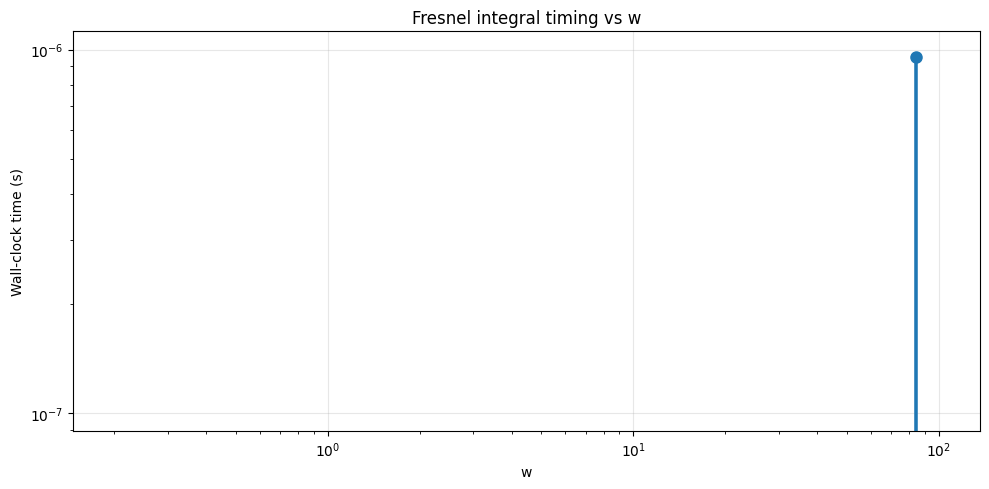

In [40]:
import subprocess
import time
import numpy as np
import matplotlib.pyplot as plt

w_values = np.linspace(0.2, 100, 20)
times = []

for w in w_values:
    t0 = time.time()
    # Run fresnel_finufft1_allw with w-specific parameters
    # (or extract timing from code output)
    t1 = time.time()
    times.append(t1 - t0)
    print(f"w={w:.1f}: {t1-t0:.3f}s")

plt.figure(figsize=(10, 5))
plt.loglog(w_values, times, 'o-', linewidth=2, markersize=8)
plt.xlabel('w'); plt.ylabel('Wall-clock time (s)')
plt.title('Fresnel integral timing vs w')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('timing_vs_w.png', dpi=150)
plt.show()

Closest y to 0.3: 0.297980 (points: 120)


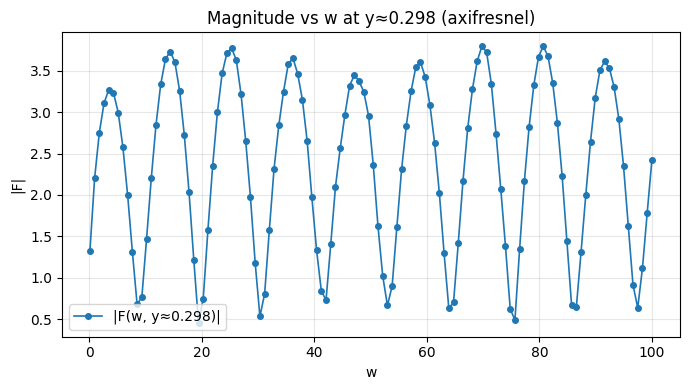

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load data from axifresnel.out
axifresnel_path = Path("/Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel/axifresnel.out")
if not axifresnel_path.exists():
    raise FileNotFoundError(f"Missing {axifresnel_path}")

data = np.loadtxt(axifresnel_path)
w = data[:, 0]
y = data[:, 1]
re_f = data[:, 2]
im_f = data[:, 3]
mag_f = np.hypot(re_f, im_f)

# Find closest y value to 1.2
target_y = 0.3
closest_y = y[np.abs(y - target_y).argmin()]
mask = np.isclose(y, closest_y, rtol=1e-6, atol=0.0)
print(f"Closest y to {target_y}: {closest_y:.6f} (points: {mask.sum()})")

w_slice = w[mask]
mag_slice = mag_f[mask]
order = np.argsort(w_slice)
w_sorted = w_slice[order]
mag_sorted = mag_slice[order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_sorted, mag_sorted, "o-", markersize=4, linewidth=1.2, label=f"|F(w, y≈{closest_y:.3f})|")
ax.set_xlabel("w")
ax.set_ylabel("|F|")
ax.set_title(f"Magnitude vs w at y≈{closest_y:.3f} (axifresnel)")
ax.grid(True, alpha=0.3)
ax.legend()
# ax.set_xlim(0,10)  # Add this line
plt.tight_layout()
plt.show()

Closest y to 0.3: 0.297980 (points: 120)


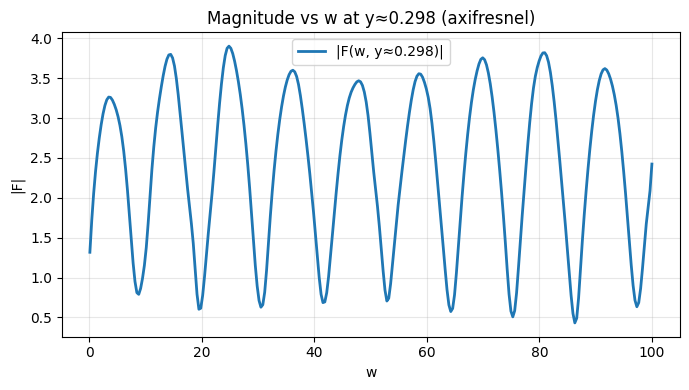

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from pathlib import Path

# Load data from axifresnel.out
axifresnel_path = Path("/Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel/axifresnel.out")
if not axifresnel_path.exists():
    raise FileNotFoundError(f"Missing {axifresnel_path}")

data = np.loadtxt(axifresnel_path)
w = data[:, 0]
y = data[:, 1]
re_f = data[:, 2]
im_f = data[:, 3]
mag_f = np.hypot(re_f, im_f)

# Find closest y value to target
target_y = 0.3
closest_y = y[np.abs(y - target_y).argmin()]
mask = np.isclose(y, closest_y, rtol=1e-6, atol=0.0)
print(f"Closest y to {target_y}: {closest_y:.6f} (points: {mask.sum()})")

w_slice = w[mask]
mag_slice = mag_f[mask]
order = np.argsort(w_slice)
w_sorted = w_slice[order]
mag_sorted = mag_slice[order]

# Fit spline to data (s=smoothing factor; adjust as needed)
spline = UnivariateSpline(w_sorted, mag_sorted, s=1e-3, k=3)
w_smooth = np.linspace(w_sorted.min(), w_sorted.max(), 300)
mag_smooth = spline(w_smooth)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_smooth, mag_smooth, "-", linewidth=2, label=f"|F(w, y≈{closest_y:.3f})|", color="C0")
ax.set_xlabel("w")
ax.set_ylabel("|F|")
ax.set_title(f"Magnitude vs w at y≈{closest_y:.3f} (axifresnel)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from pathlib import Path

# Generate 50000 Gauss-Legendre roots and weights
n = 50000
print(f"Generating {n} Gauss-Legendre points (this may take a minute)...")
roots, weights = np.polynomial.legendre.leggauss(n)

# Save to file in the project directory
output_path = Path("/Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel/gl50000")
with output_path.open("w") as f:
    for root, weight in zip(roots, weights):
        f.write(f"{root:.16e} {weight:.16e}\n")

print(f"✓ Saved {n} Gauss-Legendre points to {output_path}")
print(f"  File size: {output_path.stat().st_size / (1024**2):.1f} MB")

Generating 50000 Gauss-Legendre points (this may take a minute)...


In [66]:
import numpy as np
from pathlib import Path

# Generate 100,000 random numbers between -1 and 1
n = 10000000
print(f"Generating {n} random numbers between -1 and 1...")
x = np.random.uniform(-1, 1, n)

# Sort them
x_sorted = np.sort(x)

# Compute spacings: x_i - x_{i-1}, with x_0 = -1
spacings = np.zeros(n)
spacings[0] = x_sorted[0] - (-1.0)  # first spacing from -1
spacings[1:] = np.diff(x_sorted)    # subsequent spacings

# Save to file
output_path = Path("/Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel/gl10000000")
with output_path.open("w") as f:
    for x_i, spacing in zip(x_sorted, spacings):
        f.write(f"{x_i:.16e} {spacing:.16e}\n")

print(f"✓ Saved {n} random points (sorted) with spacings to {output_path}")
print(f"  File size: {output_path.stat().st_size / (1024**2):.1f} MB")
print(f"  Range: [{x_sorted[0]:.6f}, {x_sorted[-1]:.6f}]")
print(f"  Min spacing: {spacings.min():.6e}")
print(f"  Max spacing: {spacings.max():.6e}")
print(f"  Mean spacing: {spacings.mean():.6e}")

Generating 10000000 random numbers between -1 and 1...
✓ Saved 10000000 random points (sorted) with spacings to /Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel/gl10000000
  File size: 443.5 MB
  Range: [-1.000000, 1.000000]
  Min spacing: 2.731149e-14
  Max spacing: 3.294580e-06
  Mean spacing: 2.000000e-07


Data grid-compatible? True (w: 120, y: 100, N: 12000)


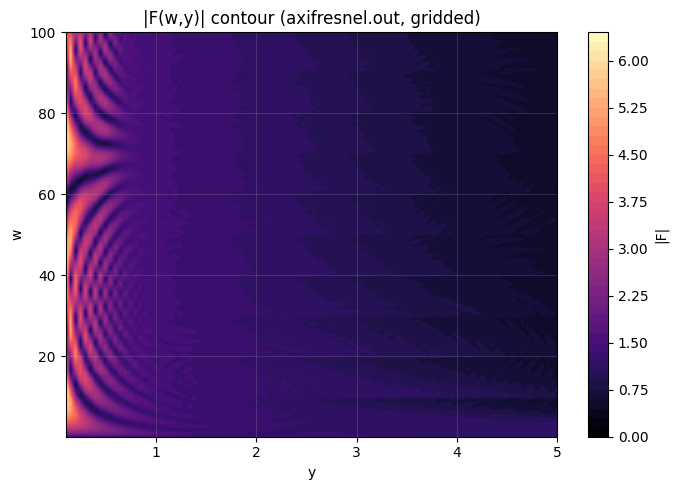

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pathlib import Path

# Contour plot of |F(w,y)| from axifresnel.out
data_path = Path("/Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel/axifresnel.out")
if not data_path.exists():
    raise FileNotFoundError(f"Missing {data_path}")

data = np.loadtxt(data_path)
w = data[:, 0]
y = data[:, 1]
re_f = data[:, 2]
im_f = data[:, 3]
amp = np.hypot(re_f, im_f)

unique_w = np.unique(w)
unique_y = np.unique(y)
N = len(w)

fig, ax = plt.subplots(figsize=(7, 5))
levels = 60

# Try gridded contour first by sorting and reshaping
can_grid = len(unique_w) * len(unique_y) == N
print(f"Data grid-compatible? {can_grid} (w: {len(unique_w)}, y: {len(unique_y)}, N: {N})")

if can_grid:
    # Sort by w then y to create w-major grid
    idx = np.lexsort((y, w))
    w_sorted = w[idx]
    y_sorted = y[idx]
    amp_sorted = amp[idx]

    try:
        Amp = amp_sorted.reshape(len(unique_w), len(unique_y))
        # Build coordinate grids
        W, Y = np.meshgrid(unique_w, unique_y, indexing="ij")
        cs = ax.contourf(Y, W, Amp, levels=levels, cmap="magma")
        cbar = fig.colorbar(cs, ax=ax, label="|F|")
        ax.set_title("|F(w,y)| contour (axifresnel.out, gridded)")
    except ValueError as e:
        print(f"Grid reshape failed: {e}; falling back to triangulation")
        tri = mtri.Triangulation(y, w)
        cs = ax.tricontourf(tri, amp, levels=levels, cmap="magma")
        cbar = fig.colorbar(cs, ax=ax, label="|F|")
        ax.set_title("|F(w,y)| contour (axifresnel.out, triangulated)")
else:
    # Use triangulation for scattered data
    tri = mtri.Triangulation(y, w)
    cs = ax.tricontourf(tri, amp, levels=levels, cmap="magma")
    cbar = fig.colorbar(cs, ax=ax, label="|F|")
    ax.set_title("|F(w,y)| contour (axifresnel.out, triangulated)")

ax.set_xlabel("y")
ax.set_ylabel("w")
ax.grid(True, alpha=0.2)


plt.tight_layout()
plt.show()

Data grid-compatible in (wy, w²-y²)? False (w·y: 1200000, w²-y²: 1200000, N: 1200000)


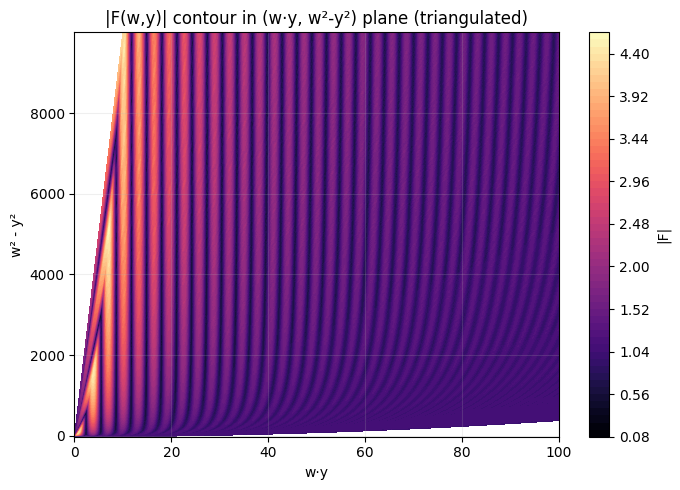

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pathlib import Path

# Contour plot of |F(w,y)| in (w·y, w²-y²) coordinate system
data_path = Path("/Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel/axifresnel.out")
if not data_path.exists():
    raise FileNotFoundError(f"Missing {data_path}")

data = np.loadtxt(data_path)
w = data[:, 0]
y = data[:, 1]
re_f = data[:, 2]
im_f = data[:, 3]
amp = np.hypot(re_f, im_f)

# Transform to (w·y, w²-y²) coordinates
wy = w * y
w2_minus_y2 = w**2 - y**2

unique_wy = np.unique(wy)
unique_diff = np.unique(w2_minus_y2)
N = len(w)

fig, ax = plt.subplots(figsize=(7, 5))
levels = 60

# Check if data forms a regular grid in new coordinates
can_grid = len(unique_wy) * len(unique_diff) == N
print(f"Data grid-compatible in (wy, w²-y²)? {can_grid} (w·y: {len(unique_wy)}, w²-y²: {len(unique_diff)}, N: {N})")

if can_grid:
    # Try to reshape into grid
    idx = np.lexsort((w2_minus_y2, wy))
    wy_sorted = wy[idx]
    diff_sorted = w2_minus_y2[idx]
    amp_sorted = amp[idx]

    try:
        Amp = amp_sorted.reshape(len(unique_wy), len(unique_diff))
        WY, DIFF = np.meshgrid(unique_wy, unique_diff, indexing="ij")
        cs = ax.contourf(WY, DIFF, Amp, levels=levels, cmap="magma")
        cbar = fig.colorbar(cs, ax=ax, label="|F|")
        ax.set_title("|F(w,y)| contour in (w·y, w²-y²) plane (gridded)")
    except ValueError as e:
        print(f"Grid reshape failed: {e}; falling back to triangulation")
        tri = mtri.Triangulation(wy, w2_minus_y2)
        cs = ax.tricontourf(tri, amp, levels=levels, cmap="magma")
        cbar = fig.colorbar(cs, ax=ax, label="|F|")
        ax.set_title("|F(w,y)| contour in (w·y, w²-y²) plane (triangulated)")
else:
    # Use triangulation for scattered data
    tri = mtri.Triangulation(wy, w2_minus_y2)
    cs = ax.tricontourf(tri, amp, levels=levels, cmap="magma")
    cbar = fig.colorbar(cs, ax=ax, label="|F|")
    ax.set_title("|F(w,y)| contour in (w·y, w²-y²) plane (triangulated)")

ax.set_xlabel("w·y")
ax.set_ylabel("w² - y²")
ax.grid(True, alpha=0.2)
ax.set_xlim(0,100)   

plt.tight_layout()
plt.show()

In [84]:
import numpy as np
from pathlib import Path

# Generate GL files for n_gl = 3000, 4000, 6000, 7000, 8000, 9000
sizes = [3000, 4000, 6000, 7000, 8000, 9000]
output_dir = Path("/Users/kamion/SCIENCE/FastHankelTransform/FHT_parallel")

for n_gl in sizes:
    print(f"Generating {n_gl} Gauss-Legendre points...")
    roots, weights = np.polynomial.legendre.leggauss(n_gl)
    
    output_path = output_dir / f"gl{n_gl}"
    with output_path.open("w") as f:
        for root, weight in zip(roots, weights):
            f.write(f"{root:.16e} {weight:.16e}\n")
    
    file_size_mb = output_path.stat().st_size / (1024**2)
    print(f"  ✓ Saved to {output_path.name} ({file_size_mb:.1f} MB)")

print("\nAll GL files generated successfully!")
print(f"Files created: gl3000, gl4000, gl6000, gl7000, gl8000, gl9000")

Generating 3000 Gauss-Legendre points...
  ✓ Saved to gl3000 (0.1 MB)
Generating 4000 Gauss-Legendre points...
  ✓ Saved to gl4000 (0.2 MB)
Generating 6000 Gauss-Legendre points...
  ✓ Saved to gl6000 (0.3 MB)
Generating 7000 Gauss-Legendre points...
  ✓ Saved to gl7000 (0.3 MB)
Generating 8000 Gauss-Legendre points...
  ✓ Saved to gl8000 (0.4 MB)
Generating 9000 Gauss-Legendre points...
  ✓ Saved to gl9000 (0.4 MB)

All GL files generated successfully!
Files created: gl3000, gl4000, gl6000, gl7000, gl8000, gl9000
